In [8]:
import json
with open('/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-14B_head_64_alpha_1.0_mygenerate.json','r') as f:
    data = json.load(f)


texts = []
for item in data:
    try:
        text = item['daiyu_answer']
        # text = text.split('</think>\n\n')[1].split(f'<|im_end|>')[0]
        texts.append(text)
    except:
        pass

len(texts)

import pandas as pd
df = pd.DataFrame({'text': texts})
df.to_csv('/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-14B_head_64_alpha_1.0_mygenerate.csv', index=False)


In [53]:
df

,text
0,I'm unable to access real-time data or externa...
1,Of course! Here are a plethora of fun activiti...
2,"Thou art most wittily writ, and thy words doth..."
3,This passage is from **William Shakespeare's *...
4,Most certainly! If the recipe calls for chicke...
...,...
395,Certainly! The best book to read depends on yo...
396,I cannot directly create or modify events in G...
397,Certainly! To help you find the **best deals o...
398,I'm most certainly unable to discern the hue t...


In [35]:
df.iloc[399]['text']

'Certainly! Here\'s an example of how to use the word **"ubiquitous"** in a sentence:\n\n**"Smartphones have become ubiquitous in modern society, with nearly every individual possessing one."**\n\nThis sentence illustrates that smartphones are **found everywhere** and are **extremely common**.'

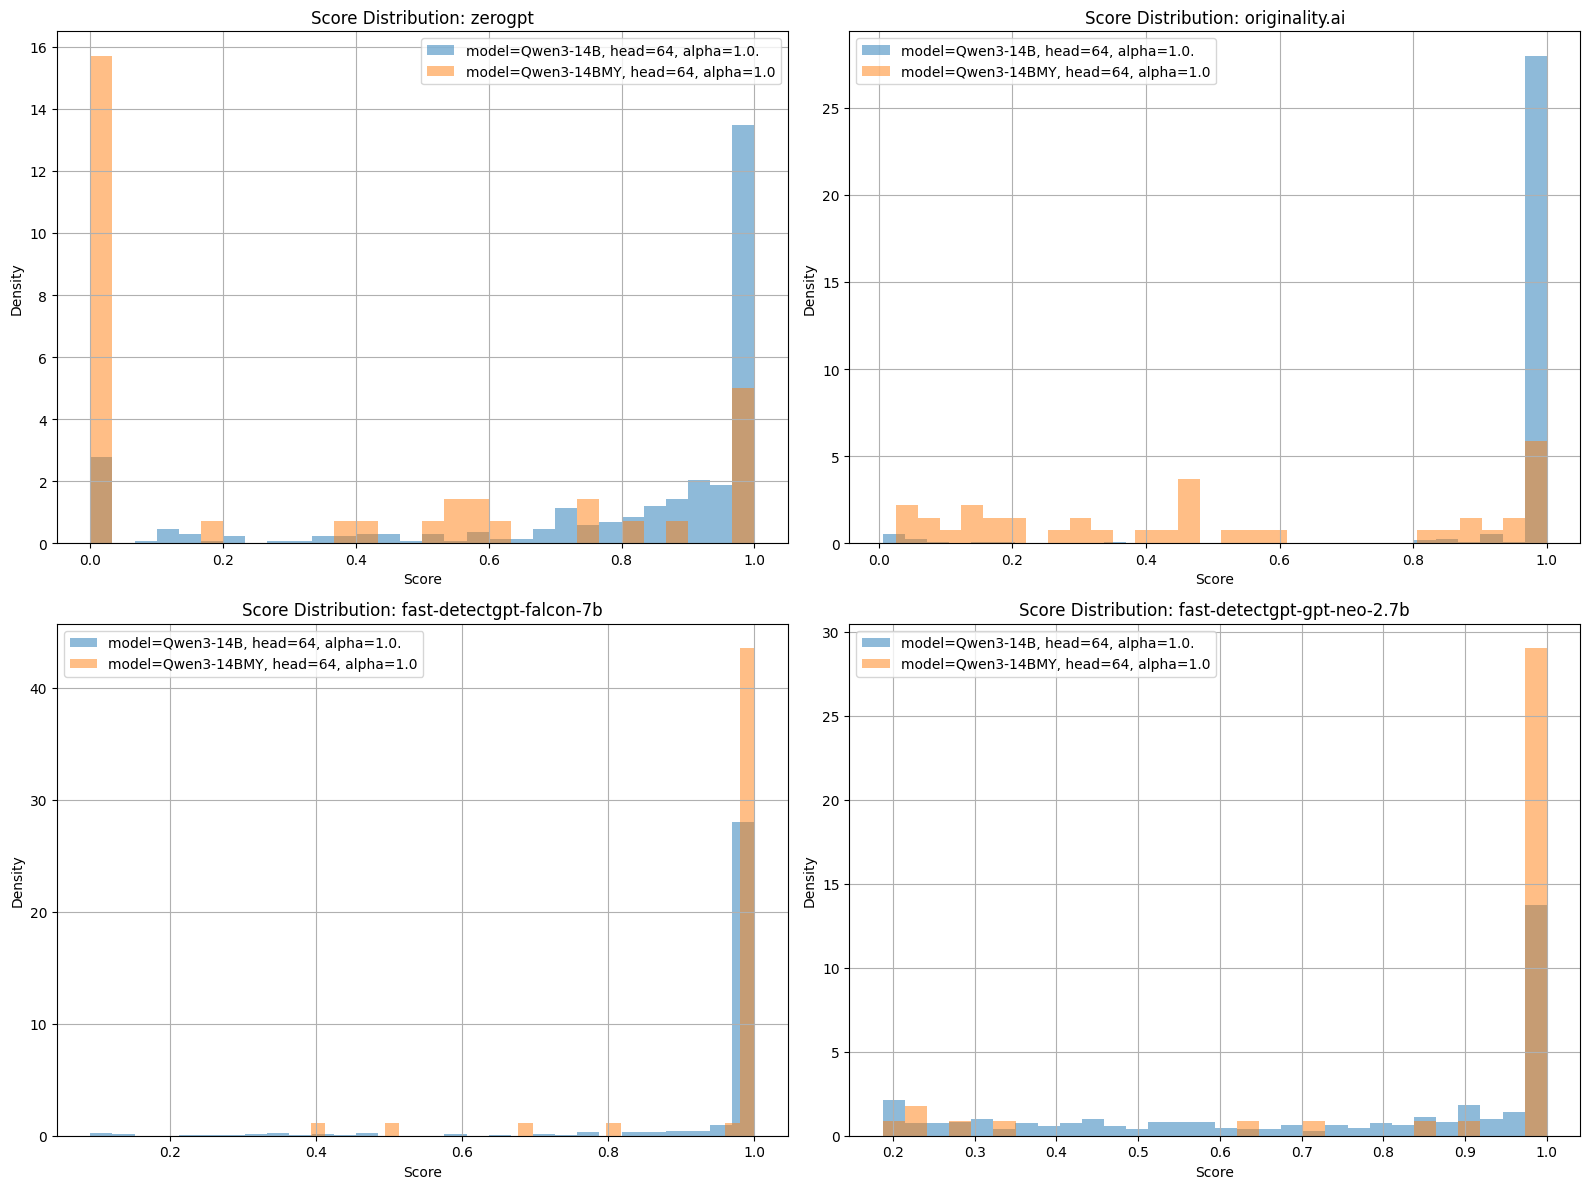

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

csv_list = [
    # '/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-4B_head_64_alpha_1.0.csv',
    # '/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-4BInstruct_head_64_alpha_1.0.csv',
    '/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-14B_head_64_alpha_1.0.csv',
    '/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-14B_head_128_alpha_1.0.csv',
    '/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-14B_head_256_alpha_1.0.csv',
    # '/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare_Qwen3-14BMY_head_64_alpha_1.0_mygenerate.csv',
    # '/data1/liyu25/ynliu/DRESS-LLM/result/mage_result_500.csv'
]

import re
def extract_alpha_head(path):
    # Extract model name (e.g., Qwen3-14B) for display, using a regex
    model_match = re.search(r'result/[^_/]+_([^/_]+)_head', path)
    alpha_match = re.search(r'alpha_([\d\.]+)', path)
    head_match = re.search(r'head_(\d+)', path)
    model = model_match.group(1) if model_match else 'unknown_model'
    alpha = alpha_match.group(1) if alpha_match else 'unknown'
    head = head_match.group(1) if head_match else 'none'
    return f'model={model}, head={head}, alpha={alpha}'

series_names = [extract_alpha_head(path) for path in csv_list]
detectors = ['zerogpt', 'originality.ai', 'fast-detectgpt-falcon-7b', 'fast-detectgpt-gpt-neo-2.7b']

dfs = [pd.read_csv(path) for path in csv_list]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, detector in enumerate(detectors):
    for df, label in zip(dfs, series_names):
        axes[idx].hist(df[detector], bins=30, alpha=0.5, density=True, label=label)
    axes[idx].set_title(f'Score Distribution: {detector}')
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel('Density')
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.show()


In [25]:
cdf = dfs[0]
print(cdf[cdf['originality.ai'] < 0.4].iloc[2]['text'])

It seemeth thou doth speake in a moste olde and curious tongue, as of yon olde Englishe of the Middes of the world, or peradventure of the quill of yon goodly M. Chaucer, or of yon goodly M. Spensere, or of yon goodly M. Marlowe. Lo, I doth hearken, and with all my might I doth atteyn to thee.

But lo, what is this name of Laun? Is it Launcelot, the goodly knight of yon Rounde Table, the fairest of the knyghtes of the Queste of the Graale, the goodly squire of yon King Arthure, the which didst love yon faire Guenievre, and was of the goodly compaignie of yon Sir Galahad, Sir Perceval, and Sir Bors? Or is it some other Laun, of yon olde chronicles, or of yon morall playes, or of yon storie of yon goodly M. Shakespere, where Launcelot, the squire of yon M. Bassanio, didst be of the goodly compaignie of yon M. Portia?

Yea, verily, I doth knowe the Launcelot of yon M. Shakespere, the which didst be a squire of yon M. Bassanio, and didst be of the goodly compaignie of yon M. Portia, and di

In [45]:
import numpy as np
df = dfs[2]
# 选择originality.ai得分小于0.05的样本
filtered_df = df[df['originality.ai'] < 0.05]

# 随机选择并拼接样本，直到拼接后长度符合要求
np.random.seed(42)  # for reproducibility
concat_samples = []
texts = list(filtered_df['text'])

for _ in range(10):
    np.random.shuffle(texts)
    temp = ""
    idx = 0
    # 按顺序添加内容直到大于3000，但不能大于4000
    while len(temp) < 3000 and idx < len(texts):
        candidate = temp + ' ' + texts[idx]
        if len(candidate) > 4000:
            break
        temp = candidate
        idx += 1
    # 如果没达到3000长度，则略过当前尝试
    if 3000 < len(temp) < 4000:
        concat_samples.append(temp)

# 如果不足10个样本，补足
while len(concat_samples) < 10:
    np.random.shuffle(texts)
    temp = ""
    idxs = np.random.choice(len(texts), size=len(texts), replace=False)
    for idx in idxs:
        candidate = temp + ' ' + texts[idx]
        if len(candidate) > 4000:
            break
        temp = candidate
        if len(temp) >= 3000:
            break
    if 3000 < len(temp) < 4000:
        concat_samples.append(temp)

# 保证只有10个样本
concat_samples = concat_samples[:10]

# 可选：打印长度查看
for i, sample in enumerate(concat_samples):
    print(f"Sample {i+1} length: {len(sample)} sample: {sample}")

# 可选：拼接的文本结果存在一个DataFrame中
concat_df = pd.DataFrame({'concat_text': concat_samples})


Sample 1 length: 3960 sample:  O, yea, doth thy mem’ry enshrine, O Sire, the Lady, whose visage, in yon diadem of yore, did sylphlike waver, e’en as the Morn’s first Lume, in Venetia’s Citade, whereto, in Companie of Marquesse, of Mountferrat, did she, a Scholler, a Souldi’r, et Venetian, hitherward, in peregrinat’ne, dehinc, in annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519, per annum, quidem, 1517, vel 1518, vel 1519